<a href="https://colab.research.google.com/github/aodm26/cardionCNN/blob/main/baselineCNN(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
# ============================================================
# Baseline CNN – Cardiomegaly Detection
# DS7023 Component 1
# ============================================================
import os, time
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

try:
    from google.colab import files, drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'PyTorch {torch.__version__}, CUDA: {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

PyTorch 2.10.0+cu128, CUDA: True
Using device: cuda


In [27]:
# Cell 2: Upload & Extract the 4 ZIPs
# ---------------------------------------------------------------------------
# Upload these 4 files when prompted:
#   trainCardiomegaly.zip, trainNo_Finding.zip, validation.zip, test.zip
#
# After extraction the script reorganises them into:
#   data/train/Cardiomegaly/       (800 images)
#   data/train/No Finding/         (800 images)
#   data/validation/Cardiomegaly/  (192 images)
#   data/validation/No Finding/    (192 images)
#   data/test/Cardiomegaly/        (100 images)
#   data/test/No Finding/          (100 images)
# ---------------------------------------------------------------------------

uploaded = files.upload()  # upload cardiomegaly_dataset.zip only
!unzip -q cardiomegaly_dataset.zip -d /content/
data_dir = '/content/data'

Saving validation.zip to validation.zip
Saving train.zip to train.zip
Saving test.zip to test.zip
replace /content/data/test/Cardiomegaly/10130-8034-24780.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: r
new name: results2
replace /content/data/test/Cardiomegaly/10134-19682-12615.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: r
new name: results22
replace /content/data/test/Cardiomegaly/10392-15312-26926.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: r
new name: 223
replace /content/data/test/Cardiomegaly/10675-21088-5761.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: r
new name: 2233
replace /content/data/test/Cardiomegaly/1071-28806-7003.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: r
new name: 234
replace /content/data/test/Cardiomegaly/10962-3694-11477.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: r
new name: 2344
replace /content/data/test/Cardiomegaly/11076-6762-12503.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 4
error:  invalid response [4]
replace /content/data/test/Cardiomegaly/11076-6762-12503.png?

In [28]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [30]:
# Cell 3: Hyperparameters & Transforms
# ---------------------------------------------------------------------------
# NOTE: Images are GRAYSCALE (mode L). We use Grayscale(3) to replicate the
# single channel across 3 channels so standard 3-channel CNN architectures
# and ImageNet normalisation statistics work correctly.
# Dataset is perfectly balanced so standard CrossEntropyLoss is sufficient.
# ---------------------------------------------------------------------------

BATCH_SIZE   = 32
NUM_EPOCHS   = 25
LR           = 1e-4
WEIGHT_DECAY = 1e-4
IMG_SIZE     = 224
SEED         = 42

torch.manual_seed(SEED); np.random.seed(SEED)

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # grayscale -> 3-ch
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

eval_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

train_ds = datasets.ImageFolder(os.path.join(data_dir, 'train'),      transform=train_tfms)
val_ds   = datasets.ImageFolder(os.path.join(data_dir, 'validation'), transform=eval_tfms)
test_ds  = datasets.ImageFolder(os.path.join(data_dir, 'test'),       transform=eval_tfms)

print(f'Classes : {train_ds.classes}  ->  {train_ds.class_to_idx}')
print(f'Train {len(train_ds)} | Val {len(val_ds)} | Test {len(test_ds)}')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

Classes : ['Cardiomegaly', 'No Finding']  ->  {'Cardiomegaly': 0, 'No Finding': 1}
Train 1600 | Val 384 | Test 200


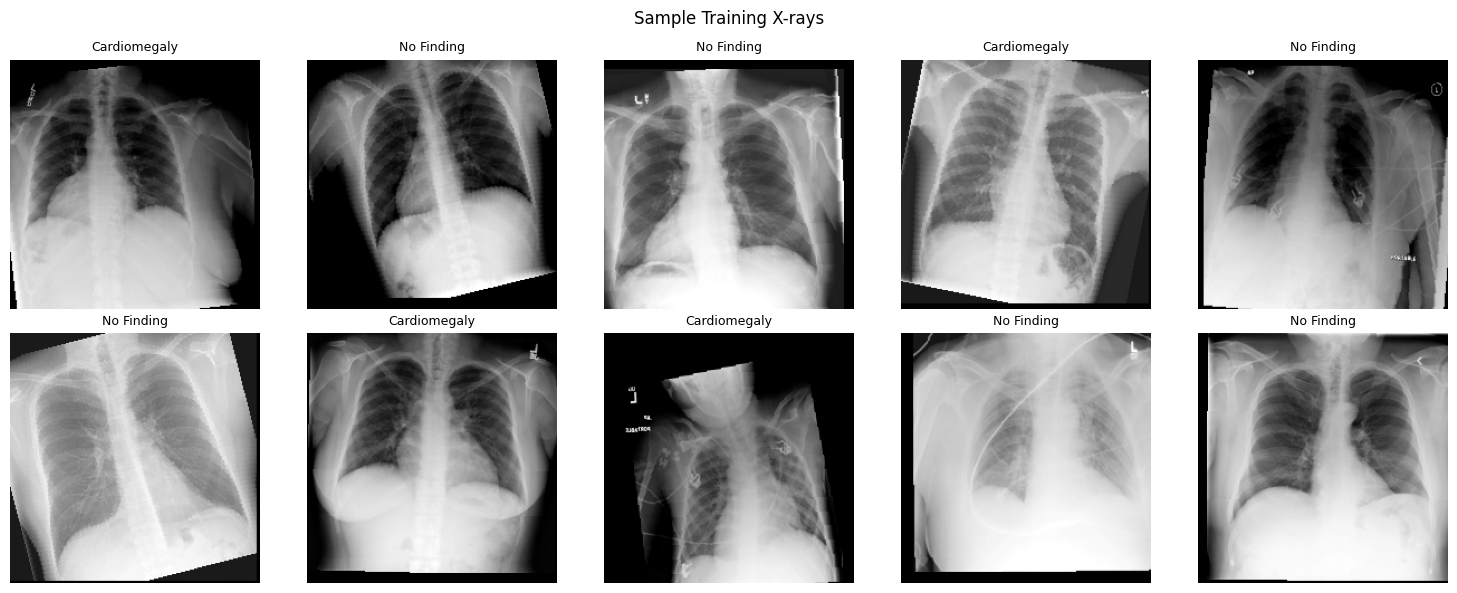

In [31]:
# Cell 4: Visualise Sample Images
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
inv = transforms.Normalize([-m/s for m,s in zip(mean,std)], [1/s for s in std])
imgs, lbls = next(iter(train_loader))
for i, ax in enumerate(axes.flat):
    img = inv(imgs[i]).permute(1,2,0).clamp(0,1).numpy()
    ax.imshow(img[:,:,0], cmap='gray')
    ax.set_title(train_ds.classes[lbls[i]], fontsize=9); ax.axis('off')
plt.suptitle('Sample Training X-rays', fontsize=12)
plt.tight_layout(); plt.savefig('sample_images.png', dpi=120); plt.show()

In [32]:
# Cell 5: Baseline CNN Architecture
# 4 conv blocks (double-conv VGG-style) + Global Avg Pool + 3-layer head
# Channels: 3->32->64->128->256  |  ~3M parameters

class CardioCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c,  out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True),
                nn.MaxPool2d(2))

        self.features = nn.Sequential(
            conv_block(3, 32), conv_block(32, 64),
            conv_block(64, 128), conv_block(128, 256))
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 512), nn.ReLU(inplace=True), nn.Dropout(0.5),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, num_classes))

    def forward(self, x):
        return self.classifier(self.pool(self.features(x)))


model = CardioCNN().to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(model)

Parameters: 1,371,682
CardioCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPo

In [33]:
# Cell 6: Loss / Optimiser / Scheduler
criterion = nn.CrossEntropyLoss()  # balanced dataset – no weighting needed
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
MODEL_PATH = 'baseline_cnn_best.pt'
print('Ready.')

Ready.


In [34]:
# Cell 7: Training Loop
def run_epoch(model, loader, optimizer=None, criterion=None, training=True):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            if training: optimizer.zero_grad()
            outs = model(imgs)
            loss = criterion(outs, lbls)
            if training: loss.backward(); optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            probs = F.softmax(outs, 1)[:, 1].detach().cpu().numpy()
            all_probs.extend(probs); all_labels.extend(lbls.cpu().numpy())
            correct += (outs.argmax(1) == lbls).sum().item(); total += lbls.size(0)
    auc = roc_auc_score(all_labels, all_probs) if len(set(all_labels)) > 1 else 0.0
    return total_loss/total, correct/total, auc, all_labels, all_probs


history = {k: [] for k in ['train_loss','train_acc','val_loss','val_acc','val_auc']}
best_auc = best_epoch = 0
print(f'Training {NUM_EPOCHS} epochs on {device}...\n')
t0 = time.time()

for ep in range(1, NUM_EPOCHS+1):
    tl,ta,_,_,_ = run_epoch(model, train_loader, optimizer, criterion, True)
    vl,va,va_auc,_,_ = run_epoch(model, val_loader, None, criterion, False)
    scheduler.step()
    for k,v in zip(['train_loss','train_acc','val_loss','val_acc','val_auc'],[tl,ta,vl,va,va_auc]):
        history[k].append(v)
    if va_auc > best_auc:
        best_auc,best_epoch = va_auc,ep; torch.save(model.state_dict(), MODEL_PATH)
    print(f'Ep {ep:02d}/{NUM_EPOCHS} | Train Loss {tl:.4f} Acc {ta:.4f} | Val Loss {vl:.4f} Acc {va:.4f} AUC {va_auc:.4f}' + (' *** BEST' if ep==best_epoch else ''))

print(f'\nDone in {(time.time()-t0)/60:.1f} min | Best Val AUC: {best_auc:.4f} @ ep {best_epoch}')

Training 25 epochs on cuda...

Ep 01/25 | Train Loss 0.6942 Acc 0.5050 | Val Loss 0.6907 Acc 0.5130 AUC 0.5675 *** BEST
Ep 02/25 | Train Loss 0.6865 Acc 0.5500 | Val Loss 0.6926 Acc 0.5182 AUC 0.5658
Ep 03/25 | Train Loss 0.6756 Acc 0.5806 | Val Loss 0.6996 Acc 0.5312 AUC 0.5854 *** BEST
Ep 04/25 | Train Loss 0.6727 Acc 0.5906 | Val Loss 0.6699 Acc 0.6042 AUC 0.6300 *** BEST
Ep 05/25 | Train Loss 0.6709 Acc 0.5981 | Val Loss 0.6816 Acc 0.5911 AUC 0.6345 *** BEST
Ep 06/25 | Train Loss 0.6639 Acc 0.6088 | Val Loss 0.6609 Acc 0.6146 AUC 0.6476 *** BEST
Ep 07/25 | Train Loss 0.6560 Acc 0.6169 | Val Loss 0.6689 Acc 0.5964 AUC 0.6480 *** BEST
Ep 08/25 | Train Loss 0.6480 Acc 0.6381 | Val Loss 0.7002 Acc 0.5495 AUC 0.6325
Ep 09/25 | Train Loss 0.6524 Acc 0.6238 | Val Loss 0.6668 Acc 0.6172 AUC 0.6516 *** BEST
Ep 10/25 | Train Loss 0.6461 Acc 0.6200 | Val Loss 0.6546 Acc 0.6302 AUC 0.6491
Ep 11/25 | Train Loss 0.6434 Acc 0.6231 | Val Loss 0.6583 Acc 0.6042 AUC 0.6553 *** BEST
Ep 12/25 | Train 

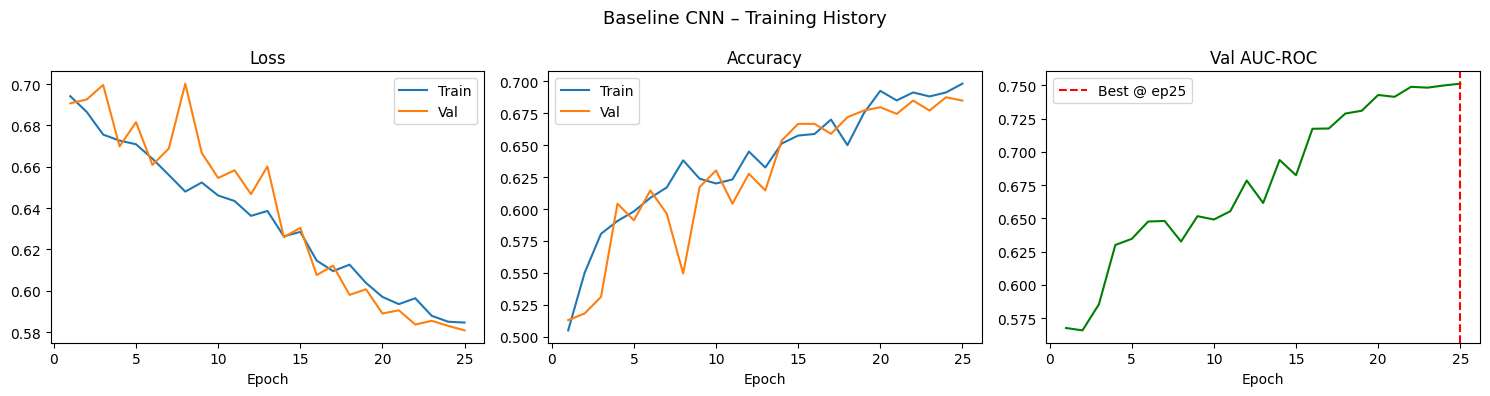

In [35]:
# Cell 8: Training Curves
eps = range(1, NUM_EPOCHS+1)
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].plot(eps,history['train_loss'],label='Train'); ax[0].plot(eps,history['val_loss'],label='Val')
ax[0].set_title('Loss'); ax[0].legend(); ax[0].set_xlabel('Epoch')
ax[1].plot(eps,history['train_acc'],label='Train'); ax[1].plot(eps,history['val_acc'],label='Val')
ax[1].set_title('Accuracy'); ax[1].legend(); ax[1].set_xlabel('Epoch')
ax[2].plot(eps,history['val_auc'],color='green')
ax[2].axvline(best_epoch,color='red',linestyle='--',label=f'Best @ ep{best_epoch}')
ax[2].set_title('Val AUC-ROC'); ax[2].legend(); ax[2].set_xlabel('Epoch')
plt.suptitle('Baseline CNN – Training History', fontsize=13)
plt.tight_layout(); plt.savefig('baseline_training_curves.png',dpi=150); plt.show()

TEST RESULTS – Baseline CNN
Accuracy : 0.6200
AUC-ROC  : 0.6682

              precision    recall  f1-score   support

Cardiomegaly       0.60      0.75      0.66       100
  No Finding       0.66      0.49      0.56       100

    accuracy                           0.62       200
   macro avg       0.63      0.62      0.61       200
weighted avg       0.63      0.62      0.61       200



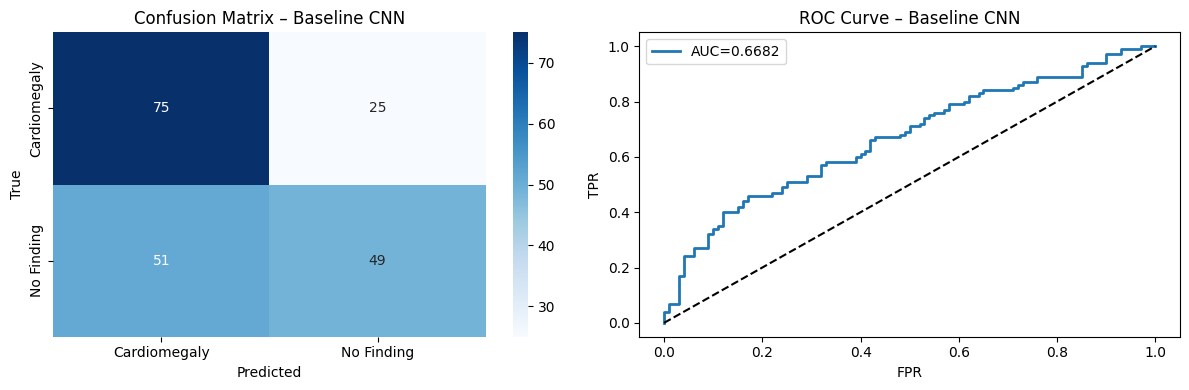

In [37]:
# Cell 9: Test Evaluation
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
_,test_acc,test_auc,y_true,y_prob = run_epoch(model, test_loader, None, criterion, False)
y_pred = [1 if p>=0.5 else 0 for p in y_prob]

print('='*55, '\nTEST RESULTS – Baseline CNN\n' + '='*55)
print(f'Accuracy : {test_acc:.4f}\nAUC-ROC  : {test_auc:.4f}\n')
print(classification_report(y_true, y_pred, target_names=train_ds.classes))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=train_ds.classes, yticklabels=train_ds.classes, ax=axes[0])
axes[0].set_title('Confusion Matrix – Baseline CNN')
axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
fpr,tpr,_ = roc_curve(y_true, y_prob)
axes[1].plot(fpr,tpr,lw=2,label=f'AUC={test_auc:.4f}'); axes[1].plot([0,1],[0,1],'k--')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve – Baseline CNN'); axes[1].legend()
plt.tight_layout(); plt.savefig('baseline_eval.png',dpi=150); plt.show()

In [38]:
# Cell 10: Download outputs
if IN_COLAB:
    for f in ['baseline_cnn_best.pt','baseline_training_curves.png','baseline_eval.png','sample_images.png']:
        files.download(f)
print('Done.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done.
